#### **Approach 3:** Group products using image processing and descriptions

## Tasks 1 & 2: Match identical/variant products

From previous EDA we observe that short descriptions in English have no missing values, while long descriptions are missing for almost all records. In this approach, we will **vectorize** short English **descriptions (using TF-IDF)** and combine them with the **image embeddings**, using either **concatenation** or **element-wise multiplication**, in order to explore the performance of each approach. Then we will use those vectors to cluster.

Our algorithms are **evaluated** on a manually labeled sample dataset. The labels correspond to variant groupings, which means that **only Task 2 can currently be evaluated**. However, Task 1 could be evaluated in a similar manner, provided we have a sample dataset labeled specifically for that task.

In [1]:
!pip install -qq torchvision
!pip install -qq hdbscan
!pip install -qq rapidfuzz

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import json
import os
from collections import Counter, defaultdict
from itertools import count, product
from tqdm import tqdm

import matplotlib.pyplot as plt
from IPython.display import display, HTML

import requests
from io import BytesIO
from PIL import Image

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import hdbscan
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, normalize

from sklearn.metrics import silhouette_score, pair_confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances

import torch
import torchvision.models as models
import torchvision.transforms as transforms

### Function to visualize products images

In [3]:
# Function to visualize clusters as HTML with an optional max_products limit
def show_clusters_as_html(df, cluster_ids, max_products=None):
    for cluster_id in cluster_ids:
        cluster_df = df[df['cluster_label'] == cluster_id]
        if cluster_df.empty:
            print(f"Cluster {cluster_id} is empty!")
            continue

        if max_products is not None:
            cluster_df = cluster_df.head(max_products)

        html = f"<h3 style='margin-top:20px'>Cluster {cluster_id} ({len(cluster_df)} items)</h3>"
        html += "<div style='display:flex;flex-wrap:wrap'>"

        for _, row in cluster_df.iterrows():
            name = row.get('product_name', '')
            
            # Choose the best available image
            for col in [
                'mainImage.original_url',
                'secondary_image_1.original_url',
                'secondary_image_2.original_url',
                'secondary_image_3.original_url'
            ]:
                img = row.get(col, '')
                if isinstance(img, str) and img.startswith('http'):
                    break
            else:
                img = ''
            
            html += f"""
                <div style='margin:10px;text-align:center'>
                    <img src='{img}' width='120' style='border-radius:8px'><br>
                    <div style='max-width:120px;font-size:12px'>{name}</div>
                </div>
            """
        html += "</div>"
        display(HTML(html))

### Create separate dataframes

In [4]:
# Load the JSON file
with open('sneakers_sample_19062025.txt', 'r', encoding='utf-8') as f:    # added encoding = utf8 otherwise: decoding error
    raw_data = json.load(f)

# Create separate dataframes
meta_rows = []
data_rows = []
sources_rows = []

# Exclude some fields that are not necessary for our tasks
exclude_fields = {
    'creation_date', 'update_date',
    'validation', 'synchronization',
    'catalogs', 'selling_authorization', "product_urls"
}

for entry in raw_data:
    # Top-level fields
    meta = {
        key: entry[key] for key in entry
        if key not in exclude_fields and key not in ['data', 'sources']
    }
    meta_rows.append(meta)
    
    # Extract nested fields (if they exist)
    if 'data' in entry:
        data_rows.append(entry['data'])
    if 'sources' in entry and isinstance(entry['sources'], list):
        for source in entry['sources']:
            # Optionally, attach product ID to track back
            source['mirakl_product_id'] = entry.get('mirakl_product_id')
            sources_rows.append(source)

# Convert all parts to DataFrames
df_meta = pd.DataFrame(meta_rows)
df_data = pd.json_normalize(data_rows)
df_sources = pd.DataFrame(sources_rows)

# Preview
print("Meta columns:", df_meta.columns.tolist())
print("Data columns:", df_data.columns.tolist())
print("Sources sample:", df_sources.head())

Meta columns: ['mirakl_product_id', 'product_sku', 'data_origin']
Data columns: ['EAN', 'size', 'brand', 'color', 'category', 'returnable', 'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'refinementColor', 'variantGroupCode', 'jiniusSkuMatchCode', 'shortDescription [el_CY]', 'shortDescription [en_GB]', 'mainImage.source', 'mainImage.original_url', 'secondary_image_1.source', 'secondary_image_1.original_url', 'secondary_image_2.source', 'secondary_image_2.original_url', 'secondary_image_3.source', 'secondary_image_3.original_url', 'longDescription [en_GB]', 'longDescription [el_CY]', 'shoeType', 'shoeShape', 'fashionMaterial', 'shoeWidth', 'heelHeight', 'name', 'heelType', 'longDescription', 'shortDescription']
Sources sample:   provider_code                               provider_sku  \
0          2077        1071A091-101--EUM-18--WHITE / BLACK   
1          2002                   VN0A3MTJT2J1--417--BLACK   
2          2167                                IH6003-44.5   
3          207

In [5]:
# Flatten 'data_origin' column
data_origin_df = pd.json_normalize(df_meta['data_origin'])

# Add prefixes so we know where they came from
data_origin_df = data_origin_df.add_prefix('origin_')

# Drop original nested columns from df_meta
df_meta = df_meta.drop(columns=['data_origin'])

# Merge the flattened parts back
df_meta = pd.concat([df_meta, data_origin_df], axis=1)

Our algorithms are **evaluated** on a manually labeled sample dataset. The labels correspond to variant groupings, which means that **only Task 2 can currently be evaluated**. However, Task 1 could be evaluated in a similar manner, provided we have a sample dataset labeled specifically for that task.

In [6]:
# Load the sample to evaluate the groups
sample_df = pd.read_csv("sample.csv")

In [7]:
# load the image embeddings for df_filtered
image_features = np.load("image_features.npy")
image_ids = pd.read_csv("image_ids.csv").iloc[:, 0].tolist()

# load the image embeddings for sample_df
clip_embeddings = np.load("clip_embeddings.npy")
clip_ids = pd.read_csv("clip_ids.csv")["mirakl_product_id"].tolist()

# Align to sample_df using mirakl_product_id
id_to_idx = {pid: i for i, pid in enumerate(clip_ids)}
sample_indices = sample_df['mirakl_product_id'].map(id_to_idx)

# Filter valid entries
valid_mask = sample_indices.notna()
sample_df = sample_df[valid_mask].reset_index(drop=True)
sample_indices = sample_indices[valid_mask].astype(int).tolist()
image_features_sample = clip_embeddings[sample_indices]

In [8]:
# Compute the cosine similarity matrix between all product image embeddings
image_sim_matrix = cosine_similarity(image_features)

In [9]:
image_sim_matrix.shape

(5679, 5679)

In [10]:
image_features.shape

(5679, 2048)

From the total of 5823 products, 5679 have at least one valid image URL. Each image embedding has length 2048.

In [11]:
# Build DataFrame for image embeddings and valid metadata
image_df = pd.DataFrame({
    'image_id': image_ids,
    'features': list(image_features)
})

# Create reverse mapping from 'row_i' fallback to real row index
image_df['row_idx'] = image_df['image_id'].apply(
    lambda x: int(x.split('_')[1]) if isinstance(x, str) and x.startswith('row_') else -1)

# Get metadata rows for valid images
df_filtered = []
for i, row in image_df.iterrows():
    if row['row_idx'] >= 0:
        meta = df_data.iloc[row['row_idx']].copy()
    else:
        meta = df_data[df_data['task1_approach1'] == row['image_id']].iloc[0].copy()
    df_filtered.append(meta)

# Convert back to DataFrame
df_filtered = pd.DataFrame(df_filtered).reset_index(drop=True)

In [12]:
image_df.head()

,image_id,features,row_idx
0,row_0,"[0.0, 0.0, 0.0, 0.0, 0.021618342, 0.0, 0.0, 0....",0
1,row_1,"[0.0, 0.0, 0.014974779, 0.039054606, 0.2362951...",1
2,row_3,"[0.0, 0.0, 0.037595145, 0.1022926, 0.14256164,...",3
3,row_4,"[0.0, 0.0, 0.0, 0.0, 0.14014705, 0.0, 0.0, 0.0...",4
4,row_5,"[0.0, 0.0, 0.01151118, 0.0, 0.5357198, 0.0, 0....",5


`filtered_df` only has the rows for which the products have at least one valid image. `image_df` includes the embedding for each image and the corresponding index (mirakle id was used for indexing).

In [13]:
print(df_data.columns.tolist())

['EAN', 'size', 'brand', 'color', 'category', 'returnable', 'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'refinementColor', 'variantGroupCode', 'jiniusSkuMatchCode', 'shortDescription [el_CY]', 'shortDescription [en_GB]', 'mainImage.source', 'mainImage.original_url', 'secondary_image_1.source', 'secondary_image_1.original_url', 'secondary_image_2.source', 'secondary_image_2.original_url', 'secondary_image_3.source', 'secondary_image_3.original_url', 'longDescription [en_GB]', 'longDescription [el_CY]', 'shoeType', 'shoeShape', 'fashionMaterial', 'shoeWidth', 'heelHeight', 'name', 'heelType', 'longDescription', 'shortDescription']


In [14]:
print(df_meta.columns.tolist())

['mirakl_product_id', 'product_sku', 'origin_name [en_GB].origin', 'origin_name [en_GB].provider_code', 'origin_name [el_CY].origin', 'origin_name [el_CY].provider_code', 'origin_color.origin', 'origin_color.provider_code', 'origin_shortDescription [el_CY].origin', 'origin_shortDescription [el_CY].provider_code', 'origin_secondary_image_2.origin', 'origin_secondary_image_2.provider_code', 'origin_secondary_image_1.origin', 'origin_secondary_image_1.provider_code', 'origin_shortDescription [en_GB].origin', 'origin_shortDescription [en_GB].provider_code', 'origin_secondary_image_3.origin', 'origin_secondary_image_3.provider_code', 'origin_mainImage.origin', 'origin_mainImage.provider_code', 'origin_returnable.origin', 'origin_size.origin', 'origin_size.provider_code', 'origin_refinementColor.origin', 'origin_category.origin', 'origin_category.provider_code', 'origin_updateOnDelta.origin', 'origin_brand.origin', 'origin_brand.provider_code', 'origin_returnable.provider_code', 'origin_long

In [15]:
print(df_sources.columns.tolist())

['provider_code', 'provider_sku', 'mirakl_product_id']


In [16]:
df_filtered.shape #correclty includes only the rows of df_data that have a valid image

(5679, 33)

In [17]:
df_filtered['product_name'] = df_filtered['name [en_GB]'].fillna('').astype(str)

#### **Approach 3:** Group products using image processing and descriptions

Vectorize product descriptions:

In [18]:
# Fill NaNs with empty strings and convert to str just in case
texts = df_filtered['shortDescription [en_GB]'].fillna('').astype(str)

# Initialize and fit the vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
text_features = vectorizer.fit_transform(texts)

In [19]:
# check the dimensionality of our text features
print(text_features.shape)

(5679, 8411)


In [20]:
# check the dimensionality of our image features
print(image_features.shape)

(5679, 2048)


To be able to combine the description embeddings with the image embeddings, we have to reduce both to the same dimension.

In [21]:
#Let's try reducing to 300 dimensions
pca_dim = 300

image_vec = PCA(n_components=pca_dim).fit_transform(image_features)
text_vec = PCA(n_components=pca_dim).fit_transform(text_features.toarray())

#### **Approach 3.1:** Combine the embeddings using concatenation

In [22]:
#combine embeddings (we concatenate but we could also try element-wise multiplication)
combined_vec = np.concatenate([image_vec, text_vec], axis=1)

#### **DBSCAN**

In [23]:
# We can tune eps and min_samples
db = DBSCAN(eps=0.5, min_samples=2, metric='euclidean')
cluster_labels = db.fit_predict(combined_vec)

# Add cluster labels back to DataFrame
df_filtered['cluster_label'] = cluster_labels

# See result
print(df_filtered[['product_name', 'cluster_label']].head())

                                 product_name  cluster_label
0  Gel-rocket 11 mens volleyball/indoor shoes             -1
1                          Mens filmore suede              0
2                 React vision worldwide mens             -1
3                       Puma men's x-ray 3 sd             -1
4                       Chuck taylor all star              1


Plot the above clustering:

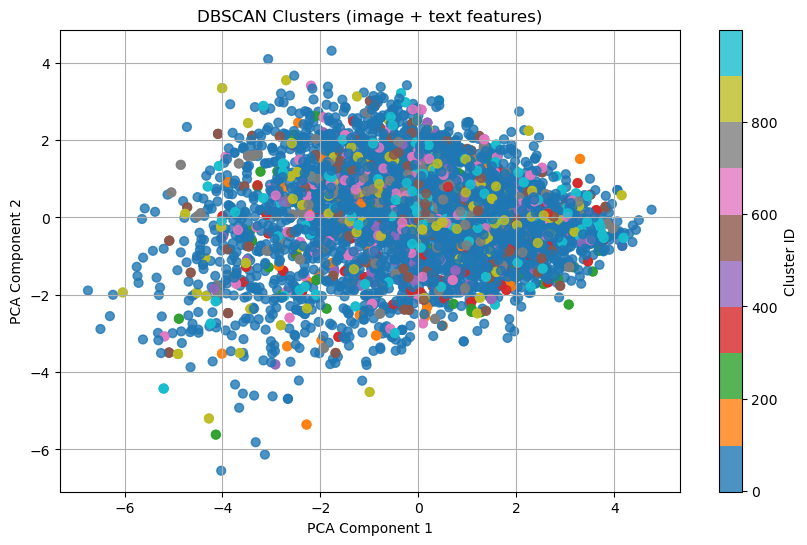

In [24]:
# Reduce to 2D for plotting
plot_embeddings = PCA(n_components=2).fit_transform(combined_vec)

db_labels = df_filtered['cluster_label'].to_numpy()

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_embeddings[:, 0], plot_embeddings[:, 1], c=cluster_labels, cmap='tab10', s=40, alpha=0.8)
plt.title("DBSCAN Clusters (image + text features)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.show()

### Compute Silhouette score

In [25]:
if len(set(db_labels)) > 1:  # silhouette score not valid if only 1 cluster
    score_dbscan = silhouette_score(combined_vec, cluster_labels)
    print("DBSCAN Silhouette Score:", round(score_dbscan, 4))

DBSCAN Silhouette Score: 0.1373


Silhouette score is small => seems like not a good clustering  

### Display images for visual inspection

In [26]:
# Exclude noise
valid_clusters = sorted(c for c in set(cluster_labels) if c != -1)

# Get first 10 clusters
selected_clusters = valid_clusters[:10]

print(f"First 10 clusters (excluding noise): {selected_clusters}")

First 10 clusters (excluding noise): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [27]:
show_clusters_as_html(df_filtered, selected_clusters)

The first 10 clusters are correct. However we cannot be sure that each cluster includes all the products. For example, there might be two (or more) clusters that have identical products or variants.

### Evaluate on sample

In [28]:
# Step 1: TF-IDF on descriptions
texts = sample_df['shortDescription [en_GB]'].fillna('').astype(str)
vectorizer = TfidfVectorizer(stop_words='english')
text_features_sample = vectorizer.fit_transform(texts)

# Step 2: Reduce both modalities with PCA
pca_dim = 300
image_vec = PCA(n_components=pca_dim).fit_transform(image_features_sample)
text_vec = PCA(n_components=pca_dim).fit_transform(text_features_sample.toarray())

In [29]:
# Step 3: Combine (concatenate) 
combined_vec_sample = np.concatenate([image_vec, text_vec], axis=1)

# Step 4: DBSCAN clustering
db = DBSCAN(eps=0.5, min_samples=2, metric='euclidean')
cluster_labels = db.fit_predict(combined_vec_sample)
sample_df['cluster_label'] = cluster_labels

# Step 5: Evaluate using micro-average precision and accuracy
y_true = sample_df['manual_group_id'].values
y_pred = sample_df['cluster_label'].values

conf_matrix = pair_confusion_matrix(y_true, y_pred)
TP, FP, FN, TN = conf_matrix[1, 1], conf_matrix[0, 1], conf_matrix[1, 0], conf_matrix[0, 0]

micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

# Step 6: Output
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = np.sum(cluster_labels == -1)

print(f"Clusters: {n_clusters}")
print(f"Noise Points: {n_noise}")
print(f"Micro-average Precision: {micro_precision:.4f}")
print(f"Micro-average Accuracy: {micro_accuracy:.4f}")

Clusters: 33
Noise Points: 879
Micro-average Precision: 0.0017
Micro-average Accuracy: 0.1396


#### **K-MEANS**

In [30]:
# number of clusters
k = 10

# Run KMeans
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(combined_vec)

# Add cluster labels to DataFrame
df_filtered['cluster_label'] = cluster_labels

# Preview
print(df_filtered[['product_name', 'cluster_label']].head())

                                 product_name  cluster_label
0  Gel-rocket 11 mens volleyball/indoor shoes              1
1                          Mens filmore suede              4
2                 React vision worldwide mens              4
3                       Puma men's x-ray 3 sd              5
4                       Chuck taylor all star              0


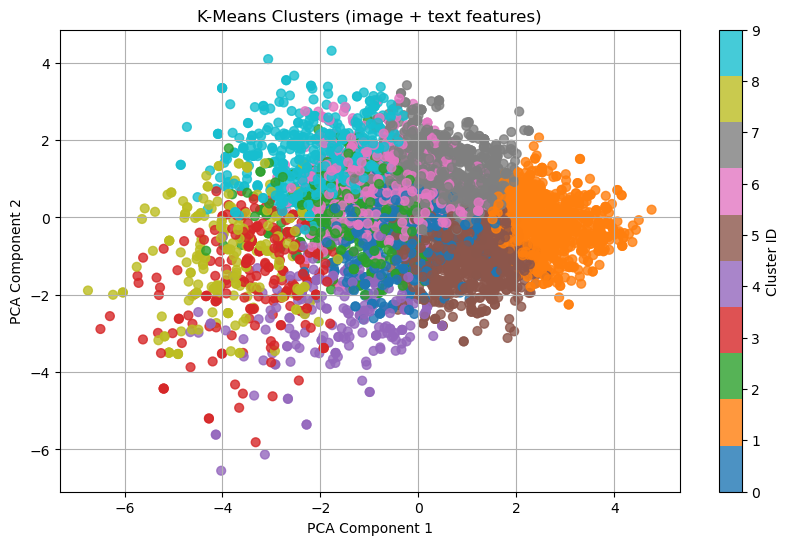

In [31]:
# Reduce to 2D
plot_vec = PCA(n_components=2).fit_transform(combined_vec)

kmeans_labels = df_filtered['cluster_label'].to_numpy()

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_vec[:, 0], plot_vec[:, 1], c=cluster_labels, cmap='tab10', s=40, alpha=0.8)
plt.title("K-Means Clusters (image + text features)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.show()

In [32]:
score_kmeans = silhouette_score(combined_vec, kmeans_labels)
print("KMeans Silhouette Score:", round(score_kmeans, 4))

KMeans Silhouette Score: 0.0328


### Display the images of the first 10 clusters:

In [33]:
# Get all unique cluster IDs
all_clusters = sorted(df_filtered['cluster_label'].unique())
print(f"All cluster IDs: {all_clusters}")

# Take first 10
selected_clusters = all_clusters[:10]

All cluster IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [34]:
# i used the max_products attribute because clusters are too big
show_clusters_as_html(df_filtered, selected_clusters, max_products = 4) 

#### **Not good clustering. No need to evaluate it on sample, since from the visual inspection we already see that it is not good.**

#### **Try to tune the number of clusters for K-Means:**

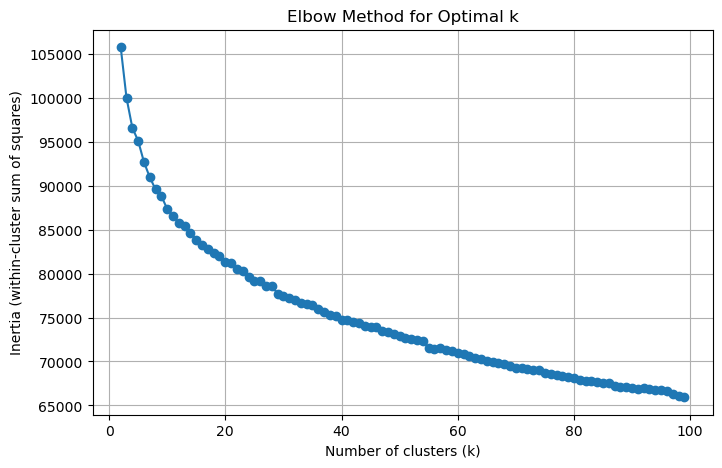

In [35]:
inertias = []
k_range = range(2, 100)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(combined_vec)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.grid(True)
plt.show()

In [36]:
inertias = []
k_range = range(800, 900)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(combined_vec)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.grid(True)
plt.show()

KeyboardInterrupt: 

Inertia doesn't level off. Might need very large k but it's computationally expensive.

#### **Agglomerative**

In [ ]:
# Choose number of clusters
n_clusters = 10

# Fit the model
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = agg.fit_predict(combined_vec)

# Assign to DataFrame
df_filtered['cluster_label'] = cluster_labels

In [ ]:
# Reduce to 2D for visualisation
plot_vec = PCA(n_components=2).fit_transform(combined_vec)

agglo_labels = df_filtered['cluster_label'].to_numpy()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_vec[:, 0], plot_vec[:, 1], c=cluster_labels, cmap='tab10', s=40)
plt.title("Agglomerative Clustering (Bottom-Up)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.show()

In [ ]:
score_agglo = silhouette_score(combined_vec, agglo_labels)
print("Agglomerative Clustering Silhouette Score:", round(score_agglo, 4))

Display images:

In [ ]:
selected_clusters = sorted(df_filtered['cluster_label'].unique())
print(f"Clusters found: {selected_clusters}")

In [ ]:
show_clusters_as_html(df_filtered, selected_clusters, max_products = 4)

#### **Not good clustering. No need to evaluate it on sample, since from the visual inspection we already see that it is not good.**

#### **Approach 3.2:** Combine embeddings using element-wise multiplication

In [ ]:
# Fill NaNs with empty strings and convert to str just in case
texts = df_filtered['shortDescription [en_GB]'].fillna('').astype(str)

# Initialize and fit the vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
text_features = vectorizer.fit_transform(texts)

#Let's try reducing to 300 dimensions
pca_dim = 300

image_vec = PCA(n_components=pca_dim).fit_transform(image_features)
text_vec = PCA(n_components=pca_dim).fit_transform(text_features.toarray())

In [ ]:
#combine the image and description (reduced) embeddings
combined_vec2 = image_vec * text_vec

#### **DBSCAN**

In [ ]:
# We can tune eps and min_samples
db = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
cluster_labels = db.fit_predict(combined_vec2)

# Add cluster labels back to DataFrame
df_filtered['cluster'] = cluster_labels

# See result
print(df_filtered[['product_name', 'cluster']].head())

In [ ]:
# Reduce to 2D for plotting
plot_embeddings = PCA(n_components=2).fit_transform(combined_vec2)

db_labels = df_filtered['cluster'].to_numpy()

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_embeddings[:, 0], plot_embeddings[:, 1], c=cluster_labels, cmap='tab10', s=40, alpha=0.8)
plt.title("DBSCAN Clusters (image + text features)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.show()

### **Compute Silhouette score**

In [ ]:
if len(set(db_labels)) > 1:  # silhouette score not valid if only 1 cluster
    score_dbscan = silhouette_score(combined_vec2, db_labels)
    print("DBSCAN Silhouette Score:", round(score_dbscan, 4))

### Evaluate on sample

In [ ]:
# Step 1: Text features from descriptions
texts = sample_df['shortDescription [en_GB]'].fillna('').astype(str)
vectorizer = TfidfVectorizer(stop_words='english')
text_features = vectorizer.fit_transform(texts)

# Step 2: Reduce both with PCA
pca_dim = 300
image_vec = PCA(n_components=pca_dim).fit_transform(image_features_sample)
text_vec = PCA(n_components=pca_dim).fit_transform(text_features.toarray())

# Step 3: Element-wise multiplication
combined_vec_sample2 = image_vec * text_vec

In [ ]:
# Step 4: Cluster with DBSCAN
db = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
cluster_labels = db.fit_predict(combined_vec_sample2)
sample_df['cluster'] = cluster_labels

# Step 5: Evaluate
y_true = sample_df['manual_group_id'].values
y_pred = sample_df['cluster'].values

conf_matrix = pair_confusion_matrix(y_true, y_pred)
TP, FP, FN, TN = conf_matrix[1, 1], conf_matrix[0, 1], conf_matrix[1, 0], conf_matrix[0, 0]

micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = np.sum(cluster_labels == -1)

print(f"Clusters: {n_clusters}")
print(f"Noise Points: {n_noise}")
print(f"Micro-average Precision: {micro_precision:.4f}")
print(f"Micro-average Accuracy: {micro_accuracy:.4f}")

#### **K-MEANS**

In [ ]:
# Choose number of clusters 
k = 10

# Run KMeans
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(combined_vec2)

# Add cluster labels to DataFrame
df_filtered['cluster'] = cluster_labels

# Preview
print(df_filtered[['product_name', 'cluster']].head())

In [ ]:
# Reduce to 2D
plot_vec = PCA(n_components=2).fit_transform(combined_vec2)

kmeans_labels = df_filtered['cluster'].to_numpy()

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_vec[:, 0], plot_vec[:, 1], c=cluster_labels, cmap='tab10', s=40, alpha=0.8)
plt.title("K-Means Clusters (image + text features)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.show()

In [ ]:
score_kmeans = silhouette_score(combined_vec2, kmeans_labels)
print("KMeans Silhouette Score:", round(score_kmeans, 4))

### Evaluate on sample

In [ ]:
# KMeans clustering
k = 10  

kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(combined_vec_sample2)

# Store labels
sample_df['cluster'] = cluster_labels

# Evaluate
y_true = sample_df['manual_group_id'].values
y_pred = sample_df['cluster'].values

conf_matrix = pair_confusion_matrix(y_true, y_pred)
TP, FP, FN, TN = conf_matrix[1, 1], conf_matrix[0, 1], conf_matrix[1, 0], conf_matrix[0, 0]

micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

print(f"Clusters: {k}")
print(f"Micro-average Precision: {micro_precision:.4f}")
print(f"Micro-average Accuracy: {micro_accuracy:.4f}")

### **Try to tune number of clusters using the Elbow method**

In [ ]:
inertias = []
k_range = range(2, 100)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(combined_vec2)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.grid(True)
plt.show()

Inertia doesn't level off. This is expected since we have more than 5000 products and we only examine a quite small number of clusters (it is quite unlikely to have only 100 clusters). However, examining for larger k would be computationally very expensive. Also, the evaluation on the sample of 1000 products would not be meaningful if we chose k to be large. Therefore, we only evaluate for a fixed k, but hyperparameter tuning is recommended as future work.

#### **Agglomerative**

In [ ]:
# Choose number of clusters
n_clusters = 10 

# Fit the model
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = agg.fit_predict(combined_vec2)

# Assign to DataFrame
df_filtered['cluster'] = cluster_labels

In [ ]:
# Reduce to 2D
plot_vec = PCA(n_components=2).fit_transform(combined_vec2)

agglo_labels = df_filtered['cluster'].to_numpy()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_vec[:, 0], plot_vec[:, 1], c=cluster_labels, cmap='tab10', s=40)
plt.title("Agglomerative Clustering (Bottom-Up)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True)
plt.show()

In [ ]:
score_agglo = silhouette_score(combined_vec2, agglo_labels)
print("Agglomerative Clustering Silhouette Score:", round(score_agglo, 4))

### Evaluate on sample

In [ ]:
# Step 1: Agglomerative Clustering
n_clusters = 10  
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = agg.fit_predict(combined_vec_sample2)

# Assign clusters
sample_df['cluster'] = cluster_labels

# Step 2: Evaluation
y_true = sample_df['manual_group_id'].values
y_pred = sample_df['cluster'].values

conf_matrix = pair_confusion_matrix(y_true, y_pred)
TP, FP, FN, TN = conf_matrix[1, 1], conf_matrix[0, 1], conf_matrix[1, 0], conf_matrix[0, 0]

micro_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
micro_accuracy = (TP + TN) / (TP + FP + FN + TN)

# Results
print(f"Clusters: {n_clusters}")
print(f"Micro-average Precision: {micro_precision:.4f}")
print(f"Micro-average Accuracy: {micro_accuracy:.4f}")